# 03 — Modeling: predict `is_adopted` (Dogs & Cats, separately)

Two algorithms, one shared pipeline, compared head to head:
- **Logistic Regression** (regularized) — interpretable baseline
- **XGBoost** — main model

**Iron rules (decided in EDA / feature selection, not changed here):**
1. Dogs and cats are modeled **separately** — their signals differ (sex dominates for cats, intake_reason for dogs); never pooled.
2. **Leakage columns never used as features:** `outcome_type, outcome_subtype, outcome_date, length_of_stay_days`.
3. **Color dropped for both species** (`primary_color, secondary_color, pattern`): floor-level mutual information (<0.002) and no AUC lift in prior tests — confirmed non-useful.

**Selected feature sets** (from the MI / Pearson feature-selection pass; `intake_month` is not among them and is therefore dropped):
- **Dog:** `intake_reason, primary_breed, intake_health_condition, sex, age_days, is_sn, is_mix`
- **Cat:** `sex, intake_reason, intake_health_condition, primary_breed, age_days, is_sn, is_mix` — `primary_breed` was a drop candidate (MI 0.001); the §9.3 ablation benefit is small and fold-dependent (≈+0.015 XGB on the 2023 fold, ≈0 on 2024) but never negative, so it is **kept**.

**Evaluation = rolling-origin backtest (not one split, not random):** for each test year *Y* in 2020–2025, train on all prior years (`intake_year < Y`) and test on *Y*. Adoption rate drifts ~0.42 → 0.65 across these years, so a random split would leak the future; the backtest instead shows how each model holds up year to year. `intake_year` is used only to build folds, never as a feature. **2025 is partial** — its fold is the least reliable.

**Leakage discipline:** every data-driven step (top-N breed thresholds, category sets) is **fit on each fold's training years only**, then applied to that fold's test year.

**`intake_reason` is a leakage SUSPECT** (highest dog MI, high cat MI): some reasons can encode the outcome. §9 ablates it (test AUC with vs without) and prints the per-category adoption breakdown for inspection — the notebook reports the delta but does **not** auto-decide.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('libraries loaded | xgboost + shap OK')

libraries loaded | xgboost + shap OK


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load, filter to dogs/cats, build `df_adopt` (rules 2–3)

In [2]:
# ====== EDIT THIS IF YOUR DATA LIVES ELSEWHERE ======
DATA_PATH = '../data/processed/df_full_merged.csv'
# ====================================================
df = pd.read_csv(DATA_PATH)
print('df raw:', df.shape)

# Euthanasia Request intakes are owner-surrendered specifically to be euthanized —
# not shelter candidates and always is_adopted=0; exclude before modeling.
before = len(df)
df = df[df['intake_reason'] != 'Euthanasia Request'].copy()
print(f'Dropped {before - len(df):,} Euthanasia Request rows -> {len(df):,} remain')

TARGET = 'is_adopted'
# Rule 4: leakage columns — listed so they are never selected as features
LEAKAGE_COLS = ['outcome_type', 'outcome_subtype', 'outcome_date',
                'length_of_stay_days']
print('leakage (never used as features):', LEAKAGE_COLS)

df raw: (162765, 25)
Dropped 243 Euthanasia Request rows -> 162,522 remain
leakage (never used as features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days']


## 3. Deterministic feature derivation (no fitting — leakage-safe)

These transforms use **no learned parameters** (fixed age bins, a fixed health-level merge), so applying them to the whole frame before the split introduces no leakage. Anything data-driven (top-N breeds) is deferred to the train-only preprocessor in §6. **Color and `intake_month` are intentionally not derived** — neither is in the selected feature sets.

In [3]:
# --- age_bucket for LR (NaN age -> its own 'Unknown' bucket) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = pd.cut(df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS,
                          right=False).astype('object').fillna('Unknown')

# --- is_sn (legal feature: recorded at intake). Unknown sex -> NaN -> explicit category for LR ---
df['is_sn_cat'] = df['is_previously_spayed_neutered'].map({1.0: 'sn_yes', 0.0: 'sn_no'}).fillna('sn_unknown')

# --- intake_health_condition: keep the well-populated levels, merge the rest into 'Other' ---
# (this folds the spec's small categories Medical/Aged/Other, plus other tiny ones, into 'Other')
HEALTH_KEEP = ['Normal', 'Injured', 'Sick', 'Nursing', 'Neonatal']
_before = df['intake_health_condition'].value_counts().to_dict()
df['intake_health_condition'] = df['intake_health_condition'].where(
    df['intake_health_condition'].isin(HEALTH_KEEP), 'Other')
# fill any stray NaN in OHE categorical inputs so encoders never choke
for c in ['sex', 'intake_reason']:
    df[c] = df[c].fillna('Missing')

print('health_condition merged ->', df['intake_health_condition'].value_counts().to_dict())
print('  (merged out of:', {k: v for k, v in _before.items() if k not in HEALTH_KEEP}, ')')
print('NOTE: color (primary/secondary/pattern) and intake_month are NOT derived — dropped per feature selection.')

health_condition merged -> {'Normal': 139889, 'Injured': 9198, 'Sick': 5906, 'Nursing': 3721, 'Other': 1926, 'Neonatal': 1882}
  (merged out of: {'Medical': 577, 'Aged': 481, 'Other': 336, 'Pregnant': 150, 'Feral': 143, 'Behavior': 80, 'Med Attn': 78, 'Unknown': 29, 'Med Urgent': 20, 'Neurologic': 11, 'Parvo': 11, 'Space': 4, 'Agonal': 4, 'Panleuk': 1, 'Congenital': 1} )
NOTE: color (primary/secondary/pattern) and intake_month are NOT derived — dropped per feature selection.


## 4. Rolling-origin backtest (expanding-window time splits)

A single 2013–22 / 2023–25 split gives one number per model and hides whether it holds up year to year. Instead we **backtest**: for each test year *Y* in 2020–2025, train on **all** prior years (`intake_year < Y`) and test on *Y* alone. The training window **expands** by one year each step:

| fold | train years | test year |
|---|---|---|
| 1 | 2013–2019 | 2020 |
| 2 | 2013–2020 | 2021 |
| 3 | 2013–2021 | 2022 |
| 4 | 2013–2022 | 2023 |
| 5 | 2013–2023 | 2024 |
| 6 | 2013–2024 | 2025 (partial) |

Every fold is strictly past → future (no leakage, no random split), and every data-driven step is re-fit on that fold's training years only. Adoption rate drifts ~0.42 → 0.65 across these years, so per-fold scores show **stability over time**, not just one lucky split. **2025 is partial** — its fold is reported but is the least reliable.

For the single-fit sections (feature ablations §9, interpretability §10) we use one **reference fold** — the most recent *complete* one: `train ≤ 2023 → test 2024`.

In [4]:
# ---- rolling-origin backtest folds: test year Y, train = all years < Y (expanding window) ----
TEST_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
REF_TEST_YEAR = 2024   # most recent COMPLETE year -> reference fold for §9/§10 (2025 is partial)

def fold_frames(test_year):
    tr = df[df.intake_year <  test_year]
    te = df[df.intake_year == test_year]
    return tr, te

print('Rolling-origin folds (expanding window):')
for Y in TEST_YEARS:
    tr, te = fold_frames(Y)
    yr0, yr1 = int(tr.intake_year.min()), int(tr.intake_year.max())
    tag = '  <- REF' if Y == REF_TEST_YEAR else ('  (partial)' if Y == 2025 else '')
    print(f'  train {yr0}-{yr1} (n={len(tr):>6,}, adopt {tr[TARGET].mean():.3f})  ->  '
          f'test {Y} (n={len(te):>5,}, adopt {te[TARGET].mean():.3f}){tag}')

# reference-fold per-species frames: reused by §5 context, §6 sanity, §9 ablations, §10 interpretability
_ref_tr, _ref_te = fold_frames(REF_TEST_YEAR)
REF_TR = {sp: _ref_tr[_ref_tr.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
REF_TE = {sp: _ref_te[_ref_te.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
print(f'\nreference fold = train <= {REF_TEST_YEAR-1} -> test {REF_TEST_YEAR}: '
      + ', '.join(f'{sp} train {len(REF_TR[sp]):,}/test {len(REF_TE[sp]):,}' for sp in ['Dog', 'Cat']))

Rolling-origin folds (expanding window):
  train 2013-2019 (n=106,708, adopt 0.466)  ->  test 2020 (n=8,853, adopt 0.538)
  train 2013-2020 (n=115,561, adopt 0.472)  ->  test 2021 (n=11,311, adopt 0.609)
  train 2013-2021 (n=126,872, adopt 0.484)  ->  test 2022 (n=11,165, adopt 0.609)
  train 2013-2022 (n=138,037, adopt 0.494)  ->  test 2023 (n=10,647, adopt 0.630)
  train 2013-2023 (n=148,684, adopt 0.504)  ->  test 2024 (n=11,101, adopt 0.653)  <- REF


  train 2013-2024 (n=159,785, adopt 0.514)  ->  test 2025 (n=2,737, adopt 0.574)  (partial)

reference fold = train <= 2023 -> test 2024: Dog train 87,268/test 5,073, Cat train 61,416/test 6,028


## 5. Per-species feature sets & breed policy

The feature sets were fixed in the MI/Pearson selection pass (see overview). Here we record them in code, set the breed policy, and print the final per-species feature list. Dogs keep breed; **cats also keep breed** — its MI was only 0.001 and the §9.3 ablation benefit is small and **fold-dependent** (≈+0.015 XGB on the 2023 fold, ≈0 on 2024), but it's neutral-to-positive and never hurts, so we keep it. Anything data-driven below (top-N breeds) is still fit on **each fold's training years only**.

In [5]:
# ---- selected feature sets (color + intake_month excluded) ----
FEATURES = {
    'Dog': ['intake_reason', 'primary_breed', 'intake_health_condition', 'sex',
            'age_days', 'is_sn', 'is_mix'],
    'Cat': ['sex', 'intake_reason', 'intake_health_condition', 'primary_breed',
            'age_days', 'is_sn', 'is_mix'],
}
DOG_BREED_TOPN, CAT_BREED_TOPN = 20, 4
BREED_TOPN = {'Dog': DOG_BREED_TOPN, 'Cat': CAT_BREED_TOPN}
# Cat breed: MI was only 0.001; the §9.3 ablation benefit is small and fold-dependent
# (~+0.015 XGB on the 2023 fold, ~0 on 2024) -> neutral-to-positive, never hurts -> KEEP.
USE_BREED  = {'Dog': True, 'Cat': True}
for sp in ['Dog', 'Cat']:
    print(f'{sp} features ({len(FEATURES[sp])}): {FEATURES[sp]}')
print('USE_BREED =', USE_BREED, '| BREED_TOPN =', BREED_TOPN)

# cat breed context: most cats are Domestic Shorthair, but the top-4 + Other split
# isolates the rarer, higher-adoption breeds that XGB exploits (see §9.3 ablation).
ct = REF_TR['Cat']
g = ct.groupby('primary_breed')[TARGET].agg(rate='mean', n='count')
g = g[g['n'] >= 100].sort_values('n', ascending=False)
print('\nCAT primary_breed adoption rate (reference-fold train, n>=100):')
print(g.round(3).to_string())
cov = ct['primary_breed'].isin(['Domestic Shorthair', 'Domestic Medium Hair',
                                'Domestic Longhair', 'Siamese']).mean()
print(f'top-{CAT_BREED_TOPN} cat breeds cover {cov:.1%} of cats; the rest fold into Other')

Dog features (7): ['intake_reason', 'primary_breed', 'intake_health_condition', 'sex', 'age_days', 'is_sn', 'is_mix']
Cat features (7): ['sex', 'intake_reason', 'intake_health_condition', 'primary_breed', 'age_days', 'is_sn', 'is_mix']
USE_BREED = {'Dog': True, 'Cat': True} | BREED_TOPN = {'Dog': 20, 'Cat': 4}



CAT primary_breed adoption rate (reference-fold train, n>=100):
                       rate      n
primary_breed                     
Domestic Shorthair    0.499  50930
Domestic Medium Hair  0.537   4956
Domestic Longhair     0.536   2287
Siamese               0.527   1872
American Shorthair    0.387    269
Snowshoe              0.600    265
Maine Coon            0.604    159
Manx                  0.538    143
Russian Blue          0.540    124
top-4 cat breeds cover 97.8% of cats; the rest fold into Other


## 6. Shared preprocessing — encoding layer splits by algorithm

Same feature *content* for both algorithms; only the **encoding** differs. The selected features map to columns as:

| feature | LR | XGBoost |
|---|---|---|
| age_days | `age_bucket` one-hot (Unknown bucket) | `age_at_intake_days` raw continuous (NaN native) |
| is_sn | **dropped** — collinear with age & redundant for the LR (§9.4) | `is_previously_spayed_neutered` raw 0/1 (NaN native) |
| sex, intake_reason, intake_health_condition | one-hot | one-hot |
| primary_breed (Dog top-20, Cat top-4) | top-N + Other (one-hot, **fit on train**) | top-N + Other |
| is_mix | passthrough 0/1 | passthrough 0/1 |

`OneHotEncoder(handle_unknown=...)` is fit only inside `.fit(X_train)`; the top-N breed grouping uses the encoder's infrequent-category mechanism, also train-fitted. **Dropped both algos:** color and `intake_month` (not in the selected sets). **Dropped from LR only:** `is_sn` (§9.4 — mild collinearity with age, ~0 predictive value for the linear model; XGB keeps it). `make_preprocessor` exposes `use_intake_reason`, `use_breed` and `lr_use_is_sn` flags so §9 can ablate them without touching the main pipeline.

In [6]:
def make_preprocessor(algo, sp, *, use_intake_reason=True, use_breed=None, lr_use_is_sn=False):
    """Build the per-(algo, species) ColumnTransformer.
    use_intake_reason / use_breed default to the production config; §9 flips them to ablate.
    lr_use_is_sn (LR only): is_sn is DROPPED from the LR by default — it is collinear with age
    and redundant for the linear model (§9.4). XGB always keeps raw is_previously_spayed_neutered
    (no coefficient-variance issue; trees can use it in interactions)."""
    if use_breed is None:
        use_breed = USE_BREED[sp]

    ohe_cols = ['sex', 'intake_health_condition']
    if use_intake_reason:
        ohe_cols = ['intake_reason'] + ohe_cols
    if algo == 'lr':
        ohe_cols += ['age_bucket']
        if lr_use_is_sn:
            ohe_cols += ['is_sn_cat']

    transformers = [('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols)]

    if use_breed:
        # top-N most frequent breeds + one 'infrequent' (=Other); unseen test breeds -> infrequent
        transformers.append(('breed',
            OneHotEncoder(handle_unknown='infrequent_if_exist',
                          max_categories=BREED_TOPN[sp] + 1, sparse_output=False),
            ['primary_breed']))

    if algo == 'lr':
        transformers.append(('mix', 'passthrough', ['is_mix']))
    else:  # xgb: keep numeric raw incl. is_previously_spayed_neutered (XGB keeps is_sn; handles NaN)
        transformers.append(('num', 'passthrough',
            ['age_at_intake_days', 'is_mix', 'is_previously_spayed_neutered']))

    return ColumnTransformer(transformers, remainder='drop')

# quick sanity: feature count per production config (on the reference fold's training frame)
for sp in ['Dog', 'Cat']:
    for algo in ['lr', 'xgb']:
        ncol = make_preprocessor(algo, sp).fit_transform(REF_TR[sp]).shape[1]
        print(f'{sp} {algo}: {ncol} features')

Dog lr: 45 features


Dog xgb: 38 features


Cat lr: 28 features
Cat xgb: 21 features


## 7. Train & backtest on every fold (LR + XGB, per species)

For each fold we fit on its training years and score on its single test year. LR is fit directly; XGB keeps the **time-aware inner tuning** — for a fold training on `≤ Y-1`, it validates on that window's **last year** to pick depth / learning-rate / n_estimators, so hyper-parameters never see the test year. Encoders, scalers and top-N breed lists are all re-fit per fold on training years only. The **reference fold** (test 2024) models are stashed for §10.

In [7]:
def evaluate(model_tag, sp, test_year, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return dict(test_year=test_year, species=sp, model=model_tag,
                AUC=roc_auc_score(y_true, proba),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                F1=f1_score(y_true, pred, zero_division=0),
                Brier=brier_score_loss(y_true, proba),
                n_test=len(y_true))

def fit_lr(train_frame, sp, use_intake_reason=True, use_breed=None, lr_use_is_sn=False):
    pipe = Pipeline([('pre', make_preprocessor('lr', sp, use_intake_reason=use_intake_reason,
                                               use_breed=use_breed, lr_use_is_sn=lr_use_is_sn)),
                     ('clf', LogisticRegression(max_iter=2000, C=1.0))])  # L2-regularized
    pipe.fit(train_frame, train_frame[TARGET])     # encoders fit on this fold's TRAIN only
    return pipe

def tune_and_fit_xgb(train_frame, sp, use_intake_reason=True, use_breed=None):
    full = train_frame
    # inner time-aware validation: hold out the LAST training year (never touches the fold's test year)
    val_year  = sorted(full.intake_year.unique())[-1]
    inner_tr  = full[full.intake_year <  val_year]
    inner_val = full[full.intake_year == val_year]
    mk = lambda: make_preprocessor('xgb', sp, use_intake_reason=use_intake_reason, use_breed=use_breed)
    pre = mk()
    Ztr, Zval = pre.fit_transform(inner_tr), pre.transform(inner_val)
    best = None
    for depth in [3, 5]:
        for lr in [0.03, 0.1]:
            m = XGBClassifier(n_estimators=800, max_depth=depth, learning_rate=lr,
                              subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                              early_stopping_rounds=30, tree_method='hist',
                              n_jobs=4, random_state=RANDOM_STATE)
            m.fit(Ztr, inner_tr[TARGET], eval_set=[(Zval, inner_val[TARGET])], verbose=False)
            if best is None or m.best_score > best['score']:
                best = dict(score=float(m.best_score), depth=depth, lr=lr, n=int(m.best_iteration) + 1)
    # refit on the FULL fold-train with chosen params (fresh preprocessor fit on full fold-train)
    pre2 = mk()
    final = XGBClassifier(n_estimators=best['n'], max_depth=best['depth'], learning_rate=best['lr'],
                          subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                          tree_method='hist', n_jobs=4, random_state=RANDOM_STATE)
    final.fit(pre2.fit_transform(full), full[TARGET])
    return pre2, final, best

BT = []           # one row per (test_year, species, model)
BT_PRED = {}      # (test_year, species, model) -> (y_true, proba), for pooled calibration/confusion
LR_MODELS = {}    # species -> reference-fold fitted Pipeline           (for §10)
XGB_MODELS = {}   # species -> reference-fold (preprocessor, booster)   (for §10)

In [8]:
# ---------------- Logistic Regression — backtest across folds ----------------
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        pipe  = fit_lr(tr, sp)
        proba = pipe.predict_proba(te)[:, 1]
        yte   = te[TARGET].values
        BT.append(evaluate('LR', sp, Y, yte, proba))
        BT_PRED[(Y, sp, 'LR')] = (yte, proba)
        if Y == REF_TEST_YEAR:
            LR_MODELS[sp] = pipe
print('LR backtest done. Per-fold test AUC (cols = test year):')
_lr = pd.DataFrame([r for r in BT if r['model'] == 'LR'])
print(_lr.pivot_table(index='species', columns='test_year', values='AUC').round(3).to_string())

LR backtest done. Per-fold test AUC (cols = test year):
test_year   2020   2021   2022   2023   2024   2025
species                                            
Cat        0.732  0.755  0.779  0.755  0.777  0.794
Dog        0.708  0.702  0.672  0.723  0.746  0.759


In [9]:
# ---------------- XGBoost — backtest across folds (time-aware inner tuning re-done per fold) ----------------
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        pre, final, best = tune_and_fit_xgb(tr, sp)
        proba = final.predict_proba(pre.transform(te))[:, 1]
        yte   = te[TARGET].values
        BT.append(evaluate('XGB', sp, Y, yte, proba))
        BT_PRED[(Y, sp, 'XGB')] = (yte, proba)
        if Y == REF_TEST_YEAR:
            XGB_MODELS[sp] = (pre, final)
    print(f'  ...XGB fold test {Y} done')
print('XGB backtest done. Per-fold test AUC (cols = test year):')
_xgb = pd.DataFrame([r for r in BT if r['model'] == 'XGB'])
print(_xgb.pivot_table(index='species', columns='test_year', values='AUC').round(3).to_string())

  ...XGB fold test 2020 done


  ...XGB fold test 2021 done


  ...XGB fold test 2022 done


  ...XGB fold test 2023 done


  ...XGB fold test 2024 done


  ...XGB fold test 2025 done
XGB backtest done. Per-fold test AUC (cols = test year):
test_year   2020   2021   2022   2023   2024   2025
species                                            
Cat        0.768  0.811  0.806  0.798  0.838  0.838
Dog        0.728  0.711  0.690  0.737  0.778  0.799


## 8. Backtest results — per-fold stability & aggregate (LR vs XGB · Dog vs Cat)

Backtest aggregate over folds (mean +/- std across test years 2020-2025):
               AUC_mean  AUC_std  F1_mean  Brier_mean  folds
species model                                               
Cat     LR        0.765    0.022    0.753       0.194      6
        XGB       0.810    0.026    0.773       0.184      6
Dog     LR        0.719    0.032    0.704       0.216      6
        XGB       0.741    0.041    0.735       0.208      6

Per-fold test AUC (rows = species | model, cols = test year):
test_year       2020   2021   2022   2023   2024   2025
species model                                          
Cat     LR     0.732  0.755  0.779  0.755  0.777  0.794
        XGB    0.768  0.811  0.806  0.798  0.838  0.838
Dog     LR     0.708  0.702  0.672  0.723  0.746  0.759
        XGB    0.728  0.711  0.690  0.737  0.778  0.799


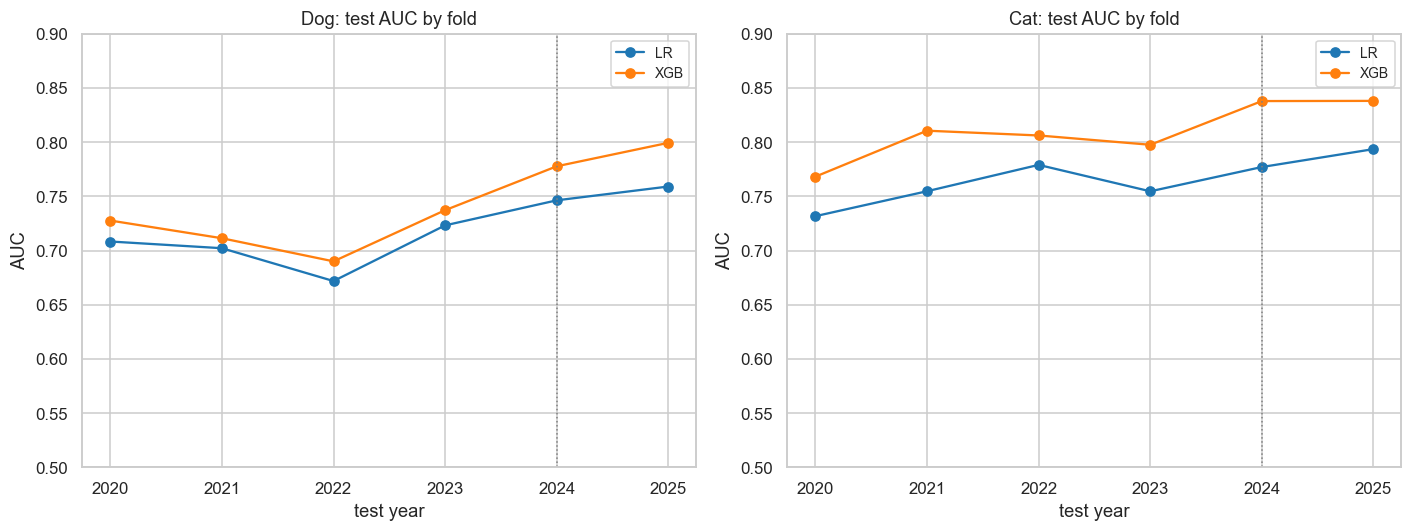

NOTE: 2025 (rightmost) is a partial year — the least reliable fold. Dotted line = reference fold.


In [10]:
bt = pd.DataFrame(BT)

# aggregate across folds (mean +/- std), per species x model — the headline backtest numbers
agg = (bt.groupby(['species', 'model'])
         .agg(AUC_mean=('AUC', 'mean'), AUC_std=('AUC', 'std'),
              F1_mean=('F1', 'mean'), Brier_mean=('Brier', 'mean'), folds=('AUC', 'size'))
         .round(3))
print('Backtest aggregate over folds (mean +/- std across test years 2020-2025):')
print(agg.to_string())

print('\nPer-fold test AUC (rows = species | model, cols = test year):')
print(bt.pivot_table(index=['species', 'model'], columns='test_year', values='AUC').round(3).to_string())

# AUC trajectory across folds, one panel per species
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for model, c in [('LR', 'tab:blue'), ('XGB', 'tab:orange')]:
        sub = bt[(bt.species == sp) & (bt.model == model)].sort_values('test_year')
        ax.plot(sub.test_year, sub.AUC, marker='o', label=model, color=c)
    ax.axvline(REF_TEST_YEAR, color='gray', ls=':', lw=1)
    ax.set_title(f'{sp}: test AUC by fold'); ax.set_xlabel('test year'); ax.set_ylabel('AUC')
    ax.set_ylim(0.5, 0.9); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()
print('NOTE: 2025 (rightmost) is a partial year — the least reliable fold. Dotted line = reference fold.')

### 8.1 Confusion matrices (threshold 0.5, predictions pooled across all backtest folds)

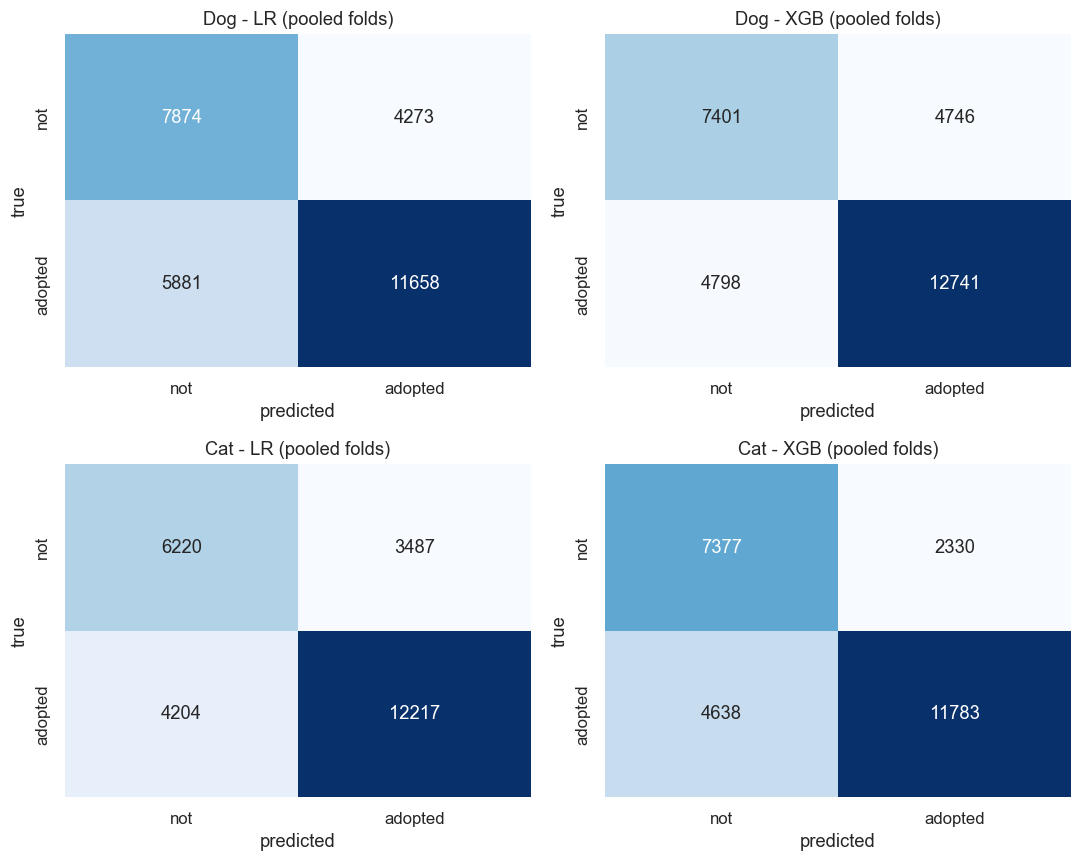

In [11]:
# pool every fold's out-of-sample predictions (each year predicted by a model trained only on its past)
def pooled(sp, tag):
    ys = np.concatenate([BT_PRED[(Y, sp, tag)][0] for Y in TEST_YEARS])
    ps = np.concatenate([BT_PRED[(Y, sp, tag)][1] for Y in TEST_YEARS])
    return ys, ps

order = [('Dog', 'LR'), ('Dog', 'XGB'), ('Cat', 'LR'), ('Cat', 'XGB')]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (sp, tag) in zip(axes.ravel(), order):
    ys, ps = pooled(sp, tag)
    cm = confusion_matrix(ys, (ps >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['not', 'adopted'], yticklabels=['not', 'adopted'])
    ax.set_title(f'{sp} - {tag} (pooled folds)'); ax.set_xlabel('predicted'); ax.set_ylabel('true')
fig.tight_layout(); plt.show()

### 8.2 Calibration (reliability), pooled across folds — essential given the time drift; AUC alone is not enough

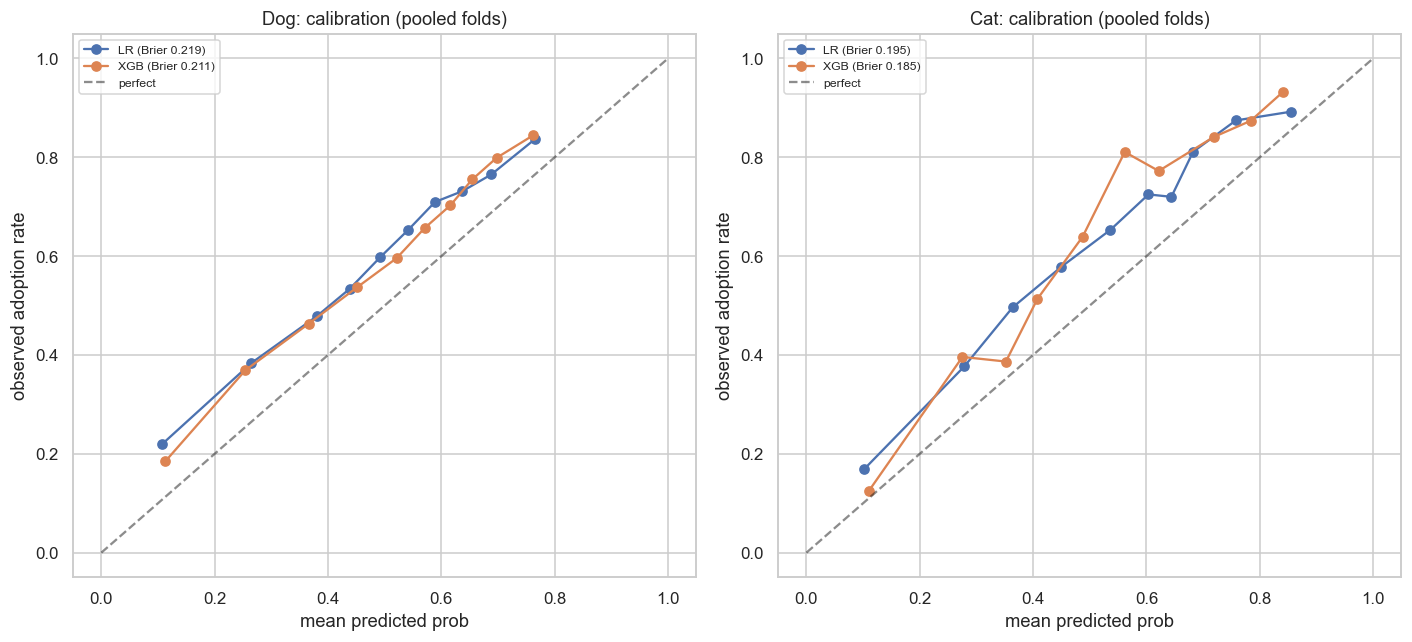

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for tag in ['LR', 'XGB']:
        ys, ps = pooled(sp, tag)
        frac, mean = calibration_curve(ys, ps, n_bins=10, strategy='quantile')
        ax.plot(mean, frac, marker='o', label=f'{tag} (Brier {brier_score_loss(ys, ps):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    ax.set_title(f'{sp}: calibration (pooled folds)'); ax.set_xlabel('mean predicted prob')
    ax.set_ylabel('observed adoption rate'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 9. Feature ablations & leakage checks (on the reference fold)

The feature questions are settled on the **reference fold** (`train ≤ 2023 → test 2024`, the most recent complete year). Looping these through every backtest fold is possible but redundant for a keep/drop decision, so we use one recent fold; encoders are re-fit on its training years, no random split.

1. **`intake_reason` — real signal or leakage?** Highest dog MI and high cat MI, but some reasons may encode the outcome. We retrain LR and XGB with vs without it and report the test-AUC delta (§9.1), plus the per-category adoption breakdown for manual inspection (§9.2). We **do not auto-decide**.
2. **`primary_breed` for cats — keep or drop?** MI was 0.001 (argues drop), so we settle it on real held-out test AUC (§9.3) rather than the MI score alone.
3. **`is_sn` × `age` collinearity (§9.4)** — `is_sn` is correlated with `age`; we quantify it (VIF) and measure what dropping it costs the LR, which motivated dropping `is_sn` from the linear model.

In [13]:
# ===== 9.1 intake_reason ablation on the reference fold: test AUC with vs without (LR + XGB) =====
def test_auc(sp, algo, use_intake_reason, use_breed=None):
    yte = REF_TE[sp][TARGET].values
    if algo == 'LR':
        pipe = fit_lr(REF_TR[sp], sp, use_intake_reason=use_intake_reason, use_breed=use_breed)
        proba = pipe.predict_proba(REF_TE[sp])[:, 1]
    else:
        pre, final, _ = tune_and_fit_xgb(REF_TR[sp], sp, use_intake_reason=use_intake_reason, use_breed=use_breed)
        proba = final.predict_proba(pre.transform(REF_TE[sp]))[:, 1]
    return roc_auc_score(yte, proba)

abl = []
for sp in ['Dog', 'Cat']:
    for algo in ['LR', 'XGB']:
        a = test_auc(sp, algo, use_intake_reason=True)
        b = test_auc(sp, algo, use_intake_reason=False)
        abl.append(dict(species=sp, model=algo, AUC_with=a, AUC_without=b, delta=a - b))
abl = pd.DataFrame(abl)
print(f'intake_reason ablation — reference fold (test {REF_TEST_YEAR}) AUC, with vs without:')
print(abl.round(4).to_string(index=False))
print('\nReading: large +delta = intake_reason carries real signal (or leakage);')
print('         delta ~ 0   = adds little -> inspect §9.2 to judge leakage vs just-weak.')
print('Caveat: "Euthanasia Request" (most outcome-coupled reason) was already dropped in §2,')
print('        so any remaining delta is from the *other* intake reasons. Not auto-decided.')

intake_reason ablation — reference fold (test 2024) AUC, with vs without:
species model  AUC_with  AUC_without  delta
    Dog    LR    0.7464       0.6954 0.0510
    Dog   XGB    0.7778       0.7134 0.0644
    Cat    LR    0.7771       0.7628 0.0143
    Cat   XGB    0.8379       0.8269 0.0110

Reading: large +delta = intake_reason carries real signal (or leakage);
         delta ~ 0   = adds little -> inspect §9.2 to judge leakage vs just-weak.
Caveat: "Euthanasia Request" (most outcome-coupled reason) was already dropped in §2,
        so any remaining delta is from the *other* intake reasons. Not auto-decided.


In [14]:
# ===== 9.2 intake_reason per-category adoption breakdown (manual leakage inspection) =====
for sp in ['Dog', 'Cat']:
    fr = df[df.animal_type == sp]
    g = (fr.groupby('intake_reason')[TARGET]
           .agg(n='count', adopt_rate='mean')
           .sort_values('n', ascending=False))
    g['adopt_rate'] = g['adopt_rate'].round(3)
    print(f'\n{sp}: intake_reason vs is_adopted')
    print(g.to_string())
print('\nFlag any category with non-trivial n whose adopt_rate sits at ~0.00 or ~1.00 —')
print('that is the signature of outcome-coupling (leakage). Stray / Owner Surrender are')
print('broad, expected intake channels and should look moderate, not extreme.')


Dog: intake_reason vs is_adopted
                     n  adopt_rate
intake_reason                     
Stray            63398       0.510
Owner Surrender  20961       0.652
Public Assist     8339       0.168
Abandoned         1080       0.677
Wildlife             1       0.000

Cat: intake_reason vs is_adopted
                     n  adopt_rate
intake_reason                     
Stray            53147       0.469
Owner Surrender  13407       0.726
Public Assist     1443       0.352
Abandoned          746       0.633

Flag any category with non-trivial n whose adopt_rate sits at ~0.00 or ~1.00 —
that is the signature of outcome-coupling (leakage). Stray / Owner Surrender are
broad, expected intake channels and should look moderate, not extreme.


In [15]:
# ===== 9.3 cat primary_breed check on the reference fold: test AUC with vs without breed =====
cat_breed_abl = []
for algo in ['LR', 'XGB']:
    a = test_auc('Cat', algo, use_intake_reason=True, use_breed=True)
    b = test_auc('Cat', algo, use_intake_reason=True, use_breed=False)
    cat_breed_abl.append(dict(model=algo, AUC_with_breed=a, AUC_without_breed=b, delta=a - b))
cba = pd.DataFrame(cat_breed_abl)
print(f'Cat primary_breed ablation — reference fold (test {REF_TEST_YEAR}) AUC, with vs without breed:')
print(cba.round(4).to_string(index=False))
xgb_delta = cba.loc[cba.model == 'XGB', 'delta'].iloc[0]
print(f'\nPolicy set in §5: USE_BREED["Cat"] = {USE_BREED["Cat"]} (breed KEPT for cats).')
print(f'XGB delta here = {xgb_delta:+.4f}. The cat-breed effect is small and FOLD-DEPENDENT')
print('(~+0.015 on the 2023 fold, ~0 on 2024): univariate MI (0.001) misses it; XGB picks it up in')
print('some folds via interactions / rare high-adoption breeds. Kept — neutral-to-positive, never hurts.')
print('For a robust verdict, loop this ablation over all backtest folds and average the delta.')

Cat primary_breed ablation — reference fold (test 2024) AUC, with vs without breed:
model  AUC_with_breed  AUC_without_breed   delta
   LR          0.7771             0.7754  0.0017
  XGB          0.8379             0.8381 -0.0002

Policy set in §5: USE_BREED["Cat"] = True (breed KEPT for cats).
XGB delta here = -0.0002. The cat-breed effect is small and FOLD-DEPENDENT
(~+0.015 on the 2023 fold, ~0 on 2024): univariate MI (0.001) misses it; XGB picks it up in
some folds via interactions / rare high-adoption breeds. Kept — neutral-to-positive, never hurts.
For a robust verdict, loop this ablation over all backtest folds and average the delta.


### 9.4 `is_sn` × `age` collinearity (LR) — measured, then dropped from the LR

`is_sn` and `age` are correlated (older animals are more often already spayed/neutered), which inflates the variance of the LR coefficients. We quantify it with **VIF** (= 1/(1−corr²)) and measure what dropping `is_sn` costs the LR on the reference fold. It turns out **mild** (VIF well below the 5–10 flag) and `is_sn` is **~redundant with age** for the linear model — so we **drop `is_sn` from the LR** (cleaner coefficients in §10.1 at ~0 AUC cost) and **keep it for XGB**, which has no coefficient-variance issue and can use it in interactions. The backtest AUC was never affected by the collinearity; only the coefficient reading was.

In [16]:
# ===== 9.4 is_sn x age collinearity in the LR (mild -> is_sn dropped from LR, kept for XGB) =====
print(f'Reference fold (train <= {REF_TEST_YEAR-1}, test {REF_TEST_YEAR}).  VIF = 1 / (1 - corr^2).')
rows = []
for sp in ['Dog', 'Cat']:
    d = REF_TR[sp]
    m = d['is_previously_spayed_neutered'].notna() & d['age_at_intake_days'].notna()
    r = np.corrcoef(d.loc[m, 'is_previously_spayed_neutered'], d.loc[m, 'age_at_intake_days'])[0, 1]
    yte = REF_TE[sp][TARGET].values
    auc_with = roc_auc_score(yte, fit_lr(REF_TR[sp], sp, lr_use_is_sn=True ).predict_proba(REF_TE[sp])[:, 1])
    auc_drop = roc_auc_score(yte, fit_lr(REF_TR[sp], sp, lr_use_is_sn=False).predict_proba(REF_TE[sp])[:, 1])
    rows.append(dict(species=sp, corr_is_sn_age=round(r, 3), VIF=round(1 / (1 - r**2), 2),
                     LR_AUC_with_is_sn=round(auc_with, 4), LR_AUC_drop_is_sn=round(auc_drop, 4),
                     delta=round(auc_drop - auc_with, 4)))
print(pd.DataFrame(rows).to_string(index=False))
print('\nVIF ~1.2-1.5 is MILD (well under the usual 5-10 flag); with L2 it never moved the backtest AUC.')
print('Dropping is_sn from the LR costs ~0 AUC -> it is redundant with age for the linear model and')
print('is the source of the age<->is_sn coefficient entanglement. DECISION: drop is_sn from the LR')
print('(cleaner §10.1 coefficients); XGB keeps it (no coefficient-variance issue, usable in interactions).')

Reference fold (train <= 2023, test 2024).  VIF = 1 / (1 - corr^2).


species  corr_is_sn_age  VIF  LR_AUC_with_is_sn  LR_AUC_drop_is_sn  delta
    Dog           0.413 1.21             0.7443             0.7464 0.0021
    Cat           0.590 1.53             0.7765             0.7771 0.0006

VIF ~1.2-1.5 is MILD (well under the usual 5-10 flag); with L2 it never moved the backtest AUC.
Dropping is_sn from the LR costs ~0 AUC -> it is redundant with age for the linear model and
is the source of the age<->is_sn coefficient entanglement. DECISION: drop is_sn from the LR
(cleaner §10.1 coefficients); XGB keeps it (no coefficient-variance issue, usable in interactions).


## 10. Interpretability — what drives adoption (reference-fold models, train ≤ 2023)

These coefficients / SHAP values come from the **reference fold's** fitted models (the same ones evaluated on test 2024), so they reflect a single, recent, leakage-safe fit — not an average over folds.

### 10.1 LR coefficients (log-odds; red = lowers, green = raises adoption odds)

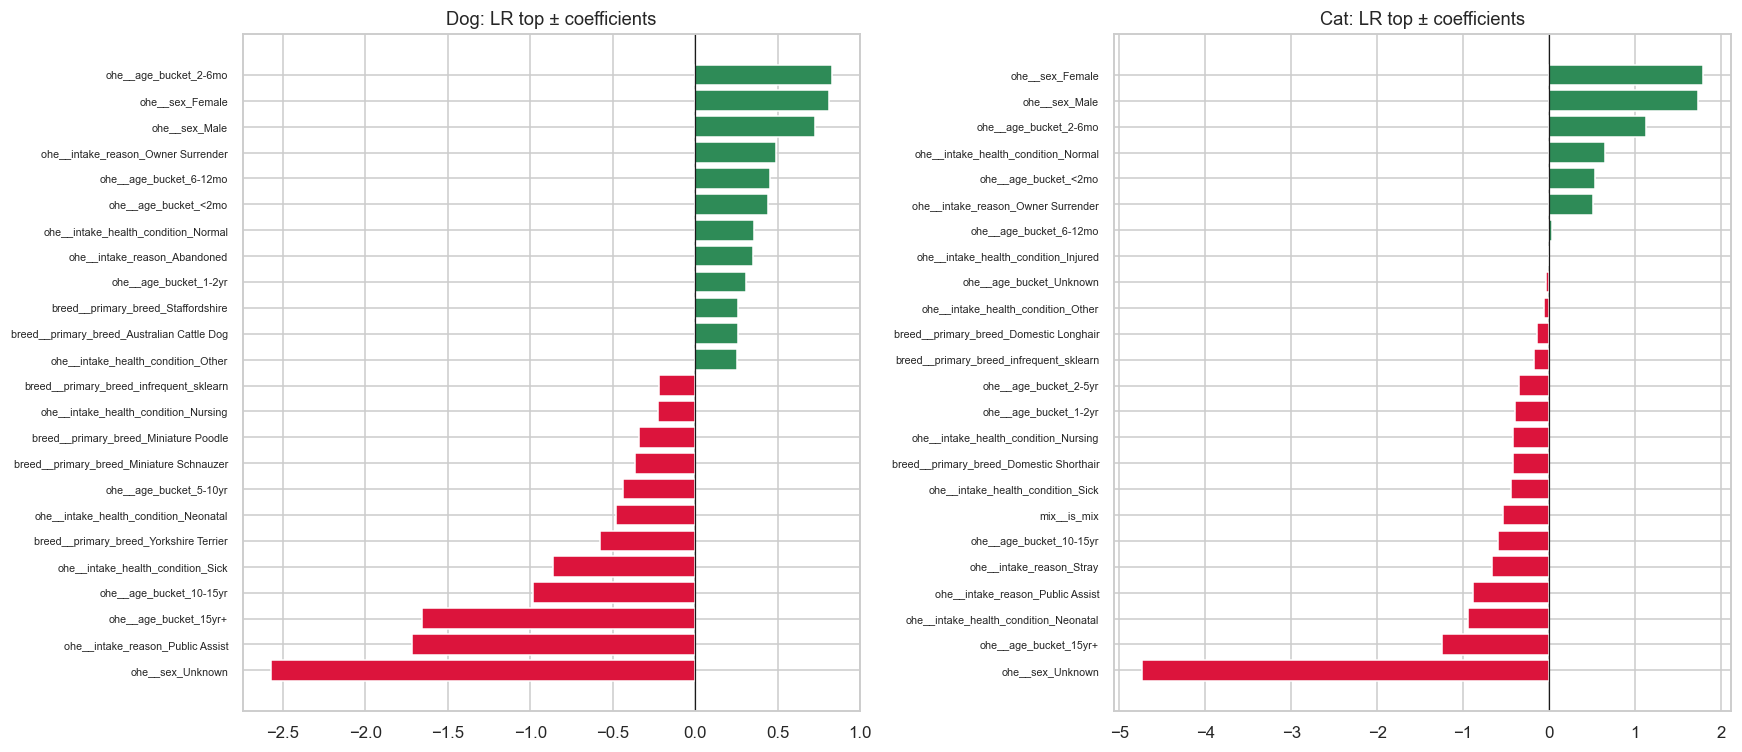

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    pipe = LR_MODELS[sp]
    names = pipe.named_steps['pre'].get_feature_names_out()
    s = pd.Series(pipe.named_steps['clf'].coef_[0], index=names).sort_values()
    top = pd.concat([s.head(12), s.tail(12)])
    ax.barh(range(len(top)), top.values,
            color=['crimson' if v < 0 else 'seagreen' for v in top.values])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
    ax.axvline(0, color='k', lw=0.8); ax.set_title(f'{sp}: LR top ± coefficients')
fig.tight_layout(); plt.show()

### 10.2 XGBoost SHAP (computed on TRAIN; not impurity importance, which is biased for high-cardinality)

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_18229/1372375209.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


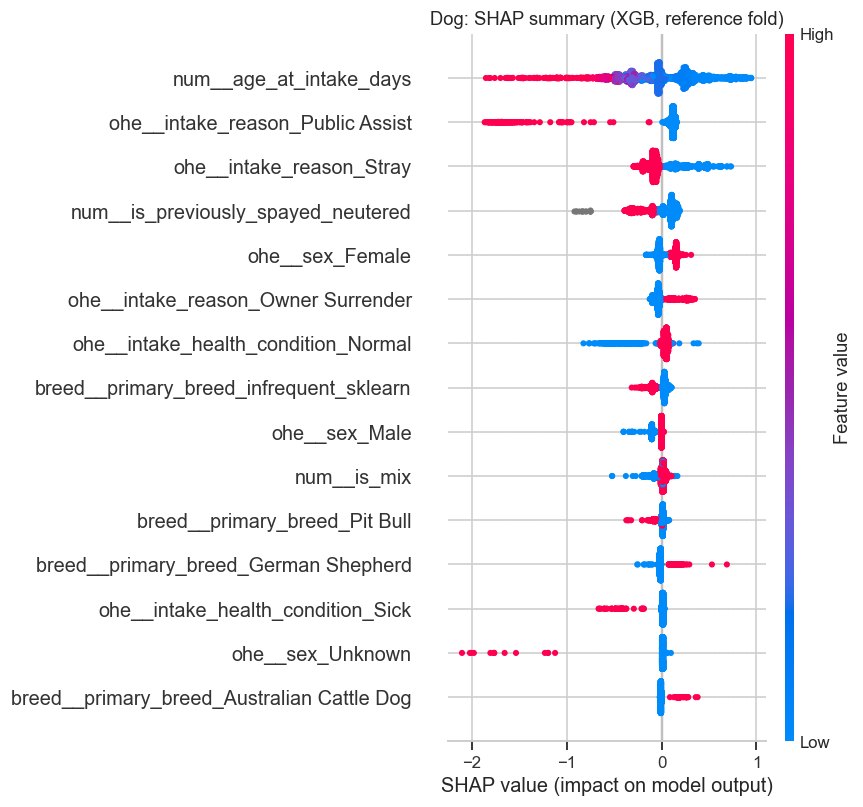

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_18229/1372375209.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


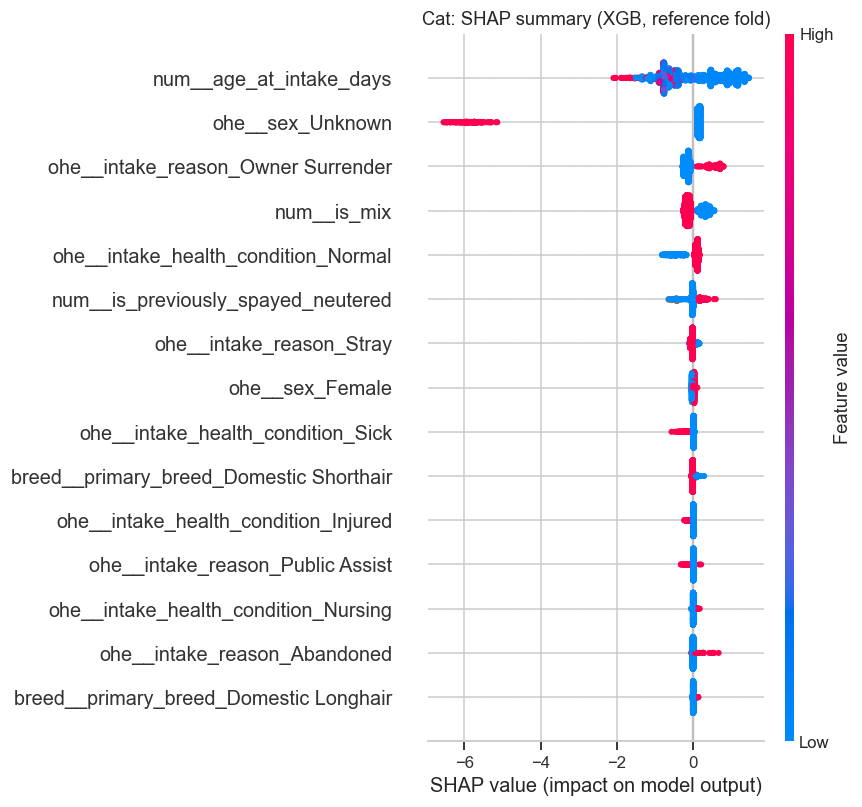

In [18]:
SHAP_INFO = {}
for sp in ['Dog', 'Cat']:
    pre, final = XGB_MODELS[sp]
    names = list(pre.get_feature_names_out())
    samp = REF_TR[sp].sample(min(2500, len(REF_TR[sp])), random_state=RANDOM_STATE)
    Z = pre.transform(samp)
    sv = shap.TreeExplainer(final).shap_values(Z)
    SHAP_INFO[sp] = (names, np.abs(sv).mean(0))
    plt.figure()
    shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)
    plt.title(f'{sp}: SHAP summary (XGB, reference fold)'); plt.tight_layout(); plt.show()

## 11. Summary (fill-in-the-blank)

### Performance (rolling-origin backtest, test years 2020–2025)
- Best model per species (by mean test AUC + calibration): dogs → ____ , cats → ____ .
- Backtest AUC (mean ± std over folds): dog LR ____ , dog XGB ____ , cat LR ____ , cat XGB ____ . Stable across folds (small std)? ____ .
- Any fold that breaks the pattern (e.g. the dog 2022 trough or the partial 2025)? ____ .
- LR vs XGBoost gap: ____ (is the extra complexity worth it across folds?).
- Calibration (pooled folds): which model's probabilities are trustworthy under the 0.42→0.65 drift? ____ .

### Feature decisions (this notebook)
- Color dropped (both species): confirmed non-useful in selection (MI <0.002, no AUC lift).
- `intake_reason` ablation (§9.1): Dog Δ AUC = ____ , Cat Δ AUC = ____ . **Kept** (recorded at intake, not the outcome). Any outcome-coupled category in §9.2? ____ .
- Cat `primary_breed` (§9.3): LR Δ AUC = ____ , XGB Δ AUC = ____ → **kept** (small, fold-dependent benefit; neutral-to-positive, never hurts).
- `is_sn` × age collinearity (§9.4): VIF ____ (dog) / ____ (cat) — mild. Dropped `is_sn` from the **LR** (~0 AUC cost, cleaner coefficients); **kept for XGB**.

### What drives adoption (per species)
- **Dogs:** top features ____ , ____ , ____ (direction).
- **Cats:** top features ____ , ____ , ____ (direction).
- Does age push opposite directions across species, as EDA predicted? ____ .

### Caveats / next steps
- Time drift is real (the backtest makes it visible) → prefer the better-calibrated model; consider recalibration / periodic retraining.
- `is_sn` × age collinearity was mild (VIF 1.2 dog / 1.5 cat) and handled by dropping the redundant `is_sn` from the LR (§9.4); it never affected the backtest AUC, only coefficient reading.
- Threshold (0.5) can be tuned to the shelter's precision/recall preference.
- If `intake_reason` is later judged leaky, retrain without it — the `use_intake_reason=False` flag is already wired through §6/§9.